# 6주차 데이터 시퀀스 생성

In [1]:
import pandas as pd
import numpy as np

In [2]:
file_path = '../../tests/data_/returns.csv'
returns = pd.read_csv(file_path, index_col=0, parse_dates=True)

print(returns.shape)

(1826, 40)


In [3]:
sp500_tickers = [
    'NVDA',   # 엔비디아
    'AAPL',   # 애플
    'MSFT',   # 마이크로소프트
    'AMZN',   # 아마존
    'GOOGL',  # 알파벳 A
    'META',   # 메타 플랫폼스
    'BRK-B',  # 버크셔 해서웨이
    'LLY',    # 일라이 릴리
    'AVGO',   # 브로드컴
    'TSLA',   # 테슬라
    'WMT',    # 월마트
    'JPM',    # JP모건 체이스
    'UNH',    # 유나이티드헬스 그룹
    'XOM',    # 엑슨모빌
    'V',      # 비자
    'MA',     # 마스터카드
    'JNJ',    # 존슨앤드존슨
    'PG',     # 프록터 앤 갬블
    'ORCL',   # 오라클
    'HD',     # 홈디포
    'COST',   # 코스트코
    'ABBV',   # 애비비
    'BAC',    # 뱅크오브아메리카
    'NFLX',   # 넷플릭스
    'CVX',    # 쉐브론
    'AMD',    # AMD
    'KO',     # 코카콜라
    'CAT',    # 캐터필러
    'PLTR',   # 팔란티어
    'MU'      # 마이크론 테크놀로지
]

crypto_tickers = [
    'BTC-USD',   # 1. 비트코인 
    'ETH-USD',   # 2. 이더리움 
    'USDT-USD',  # 3. 테더 
    'BNB-USD',   # 4. 바이낸스 코인
    'XRP-USD',   # 5. 리플 
    'USDC-USD',  # 6. 유에스디 코인
    'SOL-USD',   # 7. 솔라나 
    'TRX-USD',   # 8. 트론
    'DOGE-USD',  # 9. 도지코인 
    'ADA-USD'    # 10. 카르다노
]


In [4]:
crypto_returns = returns[crypto_tickers]
stock_returns = returns[sp500_tickers]

crypto_medians = crypto_returns.median(axis=1)
stock_medians = stock_returns.median(axis=1)

targets_crypto = crypto_returns.apply(lambda x: (x >= crypto_medians).astype(int))
targets_stock = stock_returns.apply(lambda x: (x >= stock_medians).astype(int))

# 라벨링 끝난 정답지 다시 하나로 합치기 (나중에 모델에 넣기 위함)
targets = pd.concat([targets_stock, targets_crypto], axis=1)

In [ ]:
# step_size를 Test 크기와 동일한 152로 완벽하게 수정!
def create_paper_rolling_sequences(crypto_ret, stock_ret, targets_df, seq_length, window_size=608, test_size=152, step_size=152):
    splits_data = [] 
    total_length = len(crypto_ret)
    train_size = window_size - test_size # 456일
    
    start_idx = 0
    split_count = 1
    
    # 돋보기(window_size)가 전체 데이터 끝을 넘어가지 않을 때까지 반복
    while start_idx + window_size <= total_length:
        X_train_list, y_train_list = [], []
        X_test_list, y_test_list = [], []
        
        # 1. 구간 인덱스 설정
        train_start = start_idx
        train_end = train_start + train_size
        test_end = train_start + window_size
        
        # 2. Train 구간 자르기
        train_crypto = crypto_ret.iloc[train_start:train_end]
        train_stock = stock_ret.iloc[train_start:train_end]
        
        # 3. [미래 참조 방지] 평균/표준편차 구하기
        c_mean, c_std = train_crypto.mean(), train_crypto.std()
        s_mean, s_std = train_stock.mean(), train_stock.std()
        
        # 4. 정규화
        norm_crypto = (crypto_ret.iloc[train_start:test_end] - c_mean) / c_std
        norm_stock = (stock_ret.iloc[train_start:test_end] - s_mean) / s_std
        
        norm_all = pd.concat([norm_stock, norm_crypto], axis=1)
        target_chunk = targets_df.iloc[train_start:test_end]
        
        # 5. 슬라이딩 윈도우 생성
        for ticker in norm_all.columns:
            asset_X = norm_all[ticker].values
            asset_y = target_chunk[ticker].values
            
            for j in range(len(asset_X) - seq_length):
                window = asset_X[j : j + seq_length]
                target = asset_y[j + seq_length]
                
                # 예측 대상일이 456일 경계선 이전이면 Train, 이후면 Test
                if (j + seq_length) < (train_end - train_start):
                    X_train_list.append(window)
                    y_train_list.append(target)
                else:
                    X_test_list.append(window)
                    y_test_list.append(target)
                    
        # 3차원 배열 변환
        X_train = np.expand_dims(np.array(X_train_list), -1)
        X_test = np.expand_dims(np.array(X_test_list), -1)
        y_train = np.array(y_train_list)
        y_test = np.array(y_test_list)
        
        splits_data.append((X_train, y_train, X_test, y_test))
        print(f"- Split {split_count} 생성: {train_start}일 ~ {test_end}일 (Train {len(X_train)}개, Test {len(X_test)}개)")
        
        start_idx += step_size
        split_count += 1
        
    return splits_data

print("롤링 데이터 생성")
# 파라미터 전부 맞춤
splits_30_paper = create_paper_rolling_sequences(crypto_returns, stock_returns, targets, 30, window_size=608, test_size=152, step_size=152)
print(f"\n총 {len(splits_30_paper)}개의 연구 세트가 생성")

🔥 완벽 스케일링 롤링 데이터 생성 중...
✅ Split 1 생성 완료: 0일 ~ 608일 (Train 17040개, Test 6080개)
✅ Split 2 생성 완료: 152일 ~ 760일 (Train 17040개, Test 6080개)
✅ Split 3 생성 완료: 304일 ~ 912일 (Train 17040개, Test 6080개)
✅ Split 4 생성 완료: 456일 ~ 1064일 (Train 17040개, Test 6080개)
✅ Split 5 생성 완료: 608일 ~ 1216일 (Train 17040개, Test 6080개)
✅ Split 6 생성 완료: 760일 ~ 1368일 (Train 17040개, Test 6080개)
✅ Split 7 생성 완료: 912일 ~ 1520일 (Train 17040개, Test 6080개)
✅ Split 8 생성 완료: 1064일 ~ 1672일 (Train 17040개, Test 6080개)
✅ Split 9 생성 완료: 1216일 ~ 1824일 (Train 17040개, Test 6080개)

총 9개의 연구 세트가 생성되었습니다!


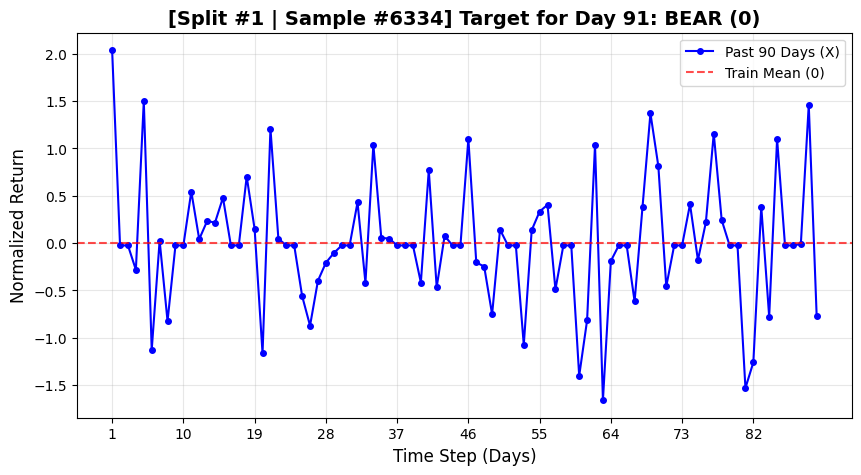

In [ ]:
import matplotlib.pyplot as plt
import random
import numpy as np

# 1. 연구 세트 선택 (0번 ~ 8번 입력 가능)
target_split = 0  

# 변수명은 현재 가지고 계신 데이터 변수명
X_train_split, y_train_split, _, _ = splits_30_paper[target_split]

# 2. 랜덤으로 문제 번호 하나 뽑기
random_idx = random.randint(0, len(X_train_split) - 1)

# 3. 데이터 가져오기
sample_X = X_train_split[random_idx].flatten() 
sample_y = y_train_split[random_idx]

# 데이터의 실제 길이를 자동으로 파악 (30이면 30, 90이면 90)
seq_len = len(sample_X)

# 4. 정답 라벨 변환
target_text = "BULL (1)" if sample_y == 1 else "BEAR (0)"

# 5. 그래프 그리기
plt.figure(figsize=(10, 5))

# X축과 데이터를 맞춤!
plt.plot(range(1, seq_len + 1), sample_X, marker='o', linestyle='-', color='b', markersize=4, label=f'Past {seq_len} Days (X)')

plt.axhline(0, color='red', linestyle='--', alpha=0.7, label='Train Mean (0)')

# 타이틀과 축도 시퀀스 길이에 맞춰서 자동 출력
plt.title(f"[Split #{target_split + 1} | Sample #{random_idx}] Target for Day {seq_len + 1}: {target_text}", fontsize=14, fontweight='bold')
plt.xlabel("Time Step (Days)", fontsize=12)
plt.ylabel("Normalized Return", fontsize=12)

# X축 눈금이 90개면 너무 지저분하니까 10일 단위 정도로 큼직하게 표시 (원리: seq_len을 10등분)
step = max(1, seq_len // 10) 
plt.xticks(range(1, seq_len + 1, step)) 

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()